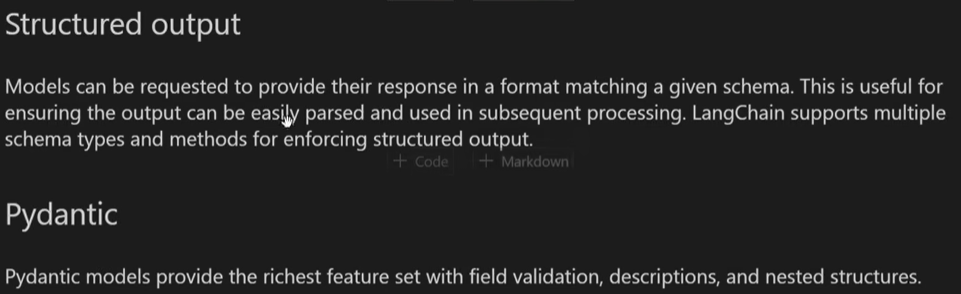

In [9]:
import os
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model = init_chat_model("groq:openai/gpt-oss-120b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F929820590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F929750C90>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [10]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    title: str = Field(description = " The Title of the movie") 
    genre: str = Field(description = " The Genre of the movie") 
    year: int = Field(description = " The release year of the movie")
    director: str = Field(description = " The director of the movie")
    rating: float = Field(description = " The rating of the movie out of 10")

In [11]:
model_with_structure = model.with_structured_output(Movie)
model_with_structure

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F929820590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F929750C90>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'description': ' The T

In [17]:
model.invoke("Hum sath sath hai")

AIMessage(content='बहुत ख़ुशी हुई यह जानकर! आज मैं आपकी कैसे मदद कर सकता हूँ? 😊', additional_kwargs={'reasoning_content': 'The user says "Hum sath sait hai" which is Hindi: "We are together". Likely they want a response. Could be a greeting or affirmation. The instruction: respond in Hindi perhaps. There\'s no disallowed content. So respond politely. Maybe ask how can I help.'}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 77, 'total_tokens': 166, 'completion_time': 0.184942965, 'completion_tokens_details': {'reasoning_tokens': 60}, 'prompt_time': 0.003249813, 'prompt_tokens_details': None, 'queue_time': 0.047901629, 'total_time': 0.188192778}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_dee443f41b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09bac-3c8e-7f71-84a1-3f52a88ebaec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_token

In [22]:
response = model_with_structure.invoke("3 Idiots")
response

Movie(title='3 Idiots', genre='Comedy drama', year=2009, director='Rajkumar Hirani', rating=8.4)

### Message Output along with Parsed structure

In [41]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    title: str = Field(description = " The Title of the movie") 
    genre: str = Field(description = " The Genre of the movie") 
    year: int = Field(description = " The release year of the movie")
    director: str = Field(description = " The director of the movie")
    rating: float = Field(description = " The rating of the movie out of 10")

model_with_structure = model.with_structured_output(Movie, include_raw=True)


response = model_with_structure.invoke("3 Idiots")
response

{'raw': AIMessage(content='', additional_kwargs={'reasoning_content': 'User says "3 Idiots". Likely they want information about the movie "3 Idiots". We have a function to get movie details: director, genre, rating, title, year. So we should call function with title "3 Idiots"? The function expects parameters: director, genre, rating, title, year. We need to fill all. We might not know all details. We can guess: 3 Idiots is a 2009 Indian Hindi-language comedy-drama film directed by Rajkumar Hirani, genre: Comedy drama, rating maybe 8.5/10, year 2009. Use that.', 'tool_calls': [{'id': 'fc_7fb2927f-5c3a-42b7-b27c-bb9bba7dce57', 'function': {'arguments': '{"director":"Rajkumar Hirani","genre":"Comedy drama","rating":8.5,"title":"3 Idiots","year":2009}', 'name': 'Movie'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 194, 'prompt_tokens': 171, 'total_tokens': 365, 'completion_time': 0.404543553, 'completion_tokens_details': {'reasoning_tokens': 130}, 'promp

### Nested Structure

In [44]:
class Actor(BaseModel):
    name: str  
    role: str

class MovieDetails(BaseModel):
    tile: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float | None = Field(None, description= "BUdget in millions USD")

model_with_structure = model.with_structured_output(MovieDetails)

response = model_with_structure.invoke("Provide Details about Movie Interstellar")
response

MovieDetails(tile='Interstellar', year=2014, cast=[Actor(name='Matthew McConaughey', role='Cooper'), Actor(name='Anne Hathaway', role='Dr. Amelia Brand'), Actor(name='Jessica Chastain', role='Murph'), Actor(name='Michael Caine', role='Professor Brand'), Actor(name='Matt Damon', role='Dr. Mann')], genres=['Science Fiction', 'Adventure', 'Drama'], budget=165000000.0)

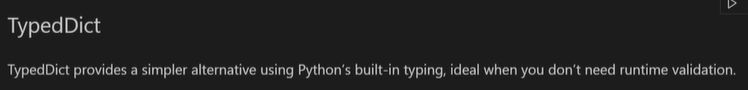

In [45]:
from typing_extensions import TypedDict,Annotated

class MovieDict(TypedDict):
    """A movie with details. """
    title: Annotated[str, ... , "The title of the movie"]
    year: Annotated[int, ... , "The year the movie was released"]
    director: Annotated[str, ... , "The director of the movie"]
    rating: Annotated[float, ... , "The movie's rating out of 10"]

model_with_typedict = model.with_structured_output(MovieDict)
response = model_with_typedict.invoke("Details about Avengers Infinity war")
response

{'director': 'Anthony Russo',
 'rating': 8.4,
 'title': 'Avengers: Infinity War',
 'year': 2018}

In [51]:
class Actor(TypedDict):
    name: str  
    role: str

class MovieDetails(TypedDict):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float 

model_with_structure = model.with_structured_output(MovieDetails)

response = model_with_structure.invoke("Provide Details about Movie Interstellar")
response

{'budget': 165000000,
 'cast': [{'name': 'Matthew McConaughey', 'role': 'Cooper'},
  {'name': 'Anne Hathaway', 'role': 'Brand'},
  {'name': 'Jessica Chastain', 'role': 'Murph (adult)'},
  {'name': 'Michael Caine', 'role': 'Professor Brand'},
  {'name': 'Mackenzie Foy', 'role': 'Murph (young)'},
  {'name': 'Casey Affleck', 'role': 'Tom'},
  {'name': 'David Gyasi', 'role': 'Romilly'},
  {'name': 'Matt Damon', 'role': 'Dr. Mann'},
  {'name': 'Bill Irwin', 'role': 'TARS (voice)'},
  {'name': 'Josh Stewart', 'role': 'Casey'}],
 'genres': ['Science Fiction', 'Adventure', 'Drama'],
 'title': 'Interstellar',
 'year': 2014}

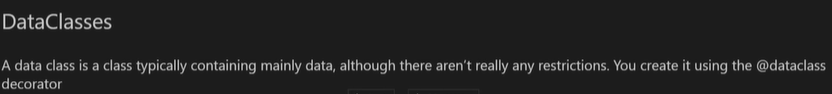

In [52]:
import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

from pydantic import BaseModel, Field
from langchain.agents import create_agent

class ContactInfo(BaseModel):
    """Contact information for a person."""
    name: str = Field(description="The name of the person")
    email: str = Field(description="The email address of the person")
    phone: str = Field(description="The phone number of the person")

agent = create_agent(
    model="gpt-5",
    response_format = ContactInfo # Auto-selects ProviderStrategy
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

print(result["structured_response"])
# ContactInfo(name='John Doe', email='john@example.com', phone=' (555) 123-4567')

OpenAIRateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}